<a href="https://colab.research.google.com/github/22wh1a04c6/Data-Science-Task/blob/main/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression

In [2]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
# from sklearn import datasets
# dir(datasets)   to see what datasets are there
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [3]:
# Data preparation
data=fetch_california_housing()
# print(data.DESCR) --> to see data description
df=pd.DataFrame(data.data,columns=data.feature_names)  #feature names is input
df[data.target_names[0]]=data.target  #target names is output
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


<Axes: xlabel='MedHouseVal', ylabel='Count'>

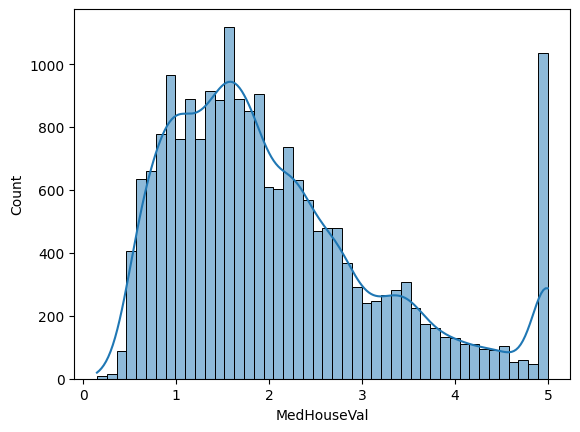

In [7]:
sns.histplot(x="MedHouseVal",data=df,kde=True)

<Axes: xlabel='HouseAge', ylabel='Count'>

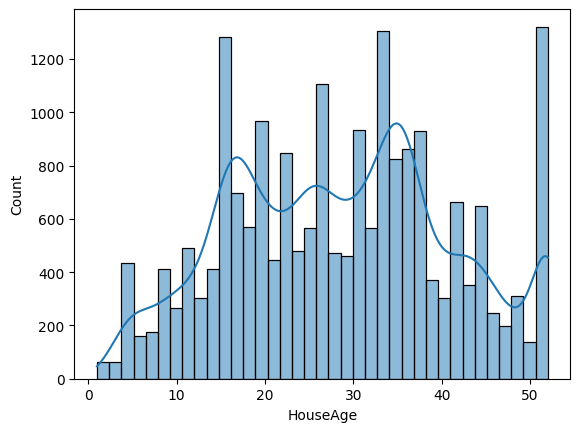

In [8]:
sns.histplot(x="HouseAge",data=df,kde=True)

<Axes: >

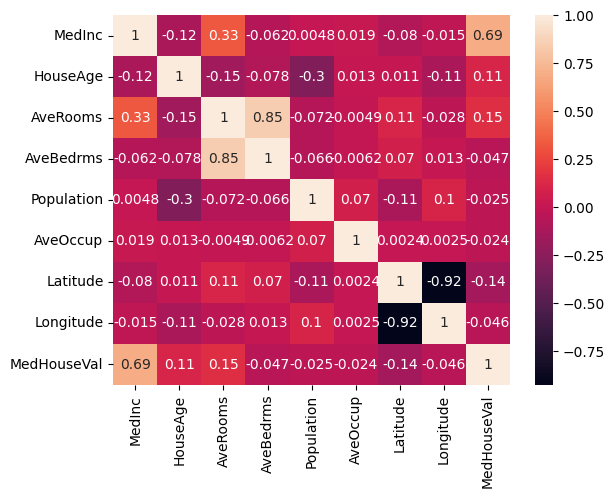

In [9]:
data=df.corr()
sns.heatmap(data,annot=True)

In [10]:
#sns.pairplot(df)

# Model Training

In [11]:
# Dividing the data into input and output
x=df.drop("MedHouseVal",axis=1)
y=df["MedHouseVal"]

In [12]:
# ML rules --> 100% --> 70%(training),30%(testing)
# Split data into training and testing
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)   #if you take train size then 0.7
# random state we should take because only 70% is for training remaining 30% is hidden for testing

In [13]:
#we should do standard scaler only after splitting
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
xtrain=sc.fit_transform(xtrain)
xtest=sc.transform(xtest)  #if we use fittransform we will be leaking data so we should use transform

In [14]:
#model training
model=LinearRegression()
model.fit(xtrain,ytrain)
#to see how slope intercept is happening use interactive ml in google

LinearRegression()

In [15]:
print(model.intercept_)  #using convergence algorithm
print(model.coef_)   #8 slopes because 8 columns are there

2.0692396089424165
[ 8.49221760e-01  1.22119309e-01 -2.99558449e-01  3.48409673e-01
 -8.84488134e-04 -4.16980388e-02 -8.93855649e-01 -8.68616688e-01]


# Model Prediction

In [16]:
ypred=model.predict(xtest)
ypred

array([0.72604907, 1.76743383, 2.71092161, ..., 2.07465531, 1.57371395,
       1.82744133])

# Model Evaluation

In [17]:
print("Metrics:")
r2=r2_score(ytest,ypred)
print("R2",r2)
N=df.shape[0]
P=df.shape[1]
adj_r2=1-(((1-r2**2)*(N-1))/N-P-1)
print("Adjusted R2",adj_r2)
print("MSE:",mean_squared_error(ytest,ypred))
print("MAE:",mean_absolute_error(ytest,ypred))

Metrics:
R2 0.5957702326061664
Adjusted R2 10.354973422861445
MSE: 0.5305677824766752
MAE: 0.5272474538305955


In [18]:
# Training   Testing     Bias   Variance
# high       high        low    low     -->Generalised model(model working well for both training and testing dataset or when we have low bias and low variance)
# high       low         low    high    -->overfitting problem(if model working well for training not for testing dataset or when we have low bias high variance)
# low        low         high   high     -->underfitting problem(model will nor work well for both training and testing dataset or when we have high bias high variance)

In [19]:
print("Training eff:",model.score(xtrain,ytrain))
print("Testing eff:",model.score(xtest,ytest))  #atleast 80% means high less than 80 means low

Training eff: 0.6093459727972159
Testing eff: 0.5957702326061664


In [20]:
new_data=df.iloc[:1,:-1]
pred=model.predict(new_data)[0]
print("Predicted price:$",pred*100000)

Predicted price:$ 8433102.211532095


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [21]:
#car price prediction file
df=pd.read_csv("car_price_prediction.csv")
df

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4


In [22]:
df.isnull().sum()

,0
ID,0
Price,0
Levy,0
Manufacturer,0
Model,0
Prod. year,0
Category,0
Leather interior,0
Fuel type,0
Engine volume,0


In [23]:
df.drop_duplicates(inplace=True)
df.shape

(18924, 18)

In [24]:
df=df.drop(["ID","Doors"],axis=1)

In [25]:
#clean levy column
df["Levy"]=df["Levy"].replace("-",np.nan)
df["Levy"]=df["Levy"].astype(float)
avg=round(df["Levy"].mean())
df["Levy"]=df["Levy"].fillna(avg)
df["Levy"].unique()

array([ 1399.,  1018.,   906.,   862.,   446.,   891.,   761.,   751.,
         394.,  1053.,  1055.,  1079.,   810.,  2386.,  1850.,   531.,
         586.,  1249.,  2455.,   583.,  1537.,  1288.,   915.,  1750.,
         707.,  1077.,  1486.,  1091.,   650.,   382.,  1436.,  1194.,
         503.,  1017.,  1104.,   639.,   629.,   919.,   781.,   530.,
         640.,   765.,   777.,   779.,   934.,   769.,   645.,  1185.,
        1324.,   830.,  1187.,  1111.,   760.,   642.,  1604.,  1095.,
         966.,   473.,  1138.,  1811.,   988.,   917.,  1156.,   687.,
       11714.,   836.,  1347.,  2866.,  1646.,   259.,   609.,   697.,
         585.,   475.,   690.,   308.,  1823.,  1361.,  1273.,   924.,
         584.,  2078.,   831.,  1172.,   893.,  1872.,  1885.,  1266.,
         447.,  2148.,  1730.,   730.,   289.,   502.,   333.,  1325.,
         247.,   879.,  1342.,  1327.,  1598.,  1514.,  1058.,   738.,
        1935.,   481.,  1522.,  1282.,   456.,   880.,   900.,   798.,
      

In [26]:
mode=df["Manufacturer"].mode()[0]
df["Manufacturer"]=df["Manufacturer"].fillna(mode)
df["Manufacturer"].unique()

array(['LEXUS', 'CHEVROLET', 'HONDA', 'FORD', 'HYUNDAI', 'TOYOTA',
       'MERCEDES-BENZ', 'OPEL', 'PORSCHE', 'BMW', 'JEEP', 'VOLKSWAGEN',
       'AUDI', 'RENAULT', 'NISSAN', 'SUBARU', 'DAEWOO', 'KIA',
       'MITSUBISHI', 'SSANGYONG', 'MAZDA', 'GMC', 'FIAT', 'INFINITI',
       'ALFA ROMEO', 'SUZUKI', 'ACURA', 'LINCOLN', 'VAZ', 'GAZ',
       'CITROEN', 'LAND ROVER', 'MINI', 'DODGE', 'CHRYSLER', 'JAGUAR',
       'ISUZU', 'SKODA', 'DAIHATSU', 'BUICK', 'TESLA', 'CADILLAC',
       'PEUGEOT', 'BENTLEY', 'VOLVO', 'სხვა', 'HAVAL', 'HUMMER', 'SCION',
       'UAZ', 'MERCURY', 'ZAZ', 'ROVER', 'SEAT', 'LANCIA', 'MOSKVICH',
       'MASERATI', 'FERRARI', 'SAAB', 'LAMBORGHINI', 'ROLLS-ROYCE',
       'PONTIAC', 'SATURN', 'ASTON MARTIN', 'GREATWALL'], dtype=object)

In [27]:
# cleaning engine volume column
df["Engine volume"]=df["Engine volume"].str.strip("Turbo")
df["Engine volume"]=df["Engine volume"].astype(float)
df["Engine volume"].unique()

array([ 3.5,  3. ,  1.3,  2.5,  2. ,  1.8,  2.4,  4. ,  1.6,  3.3,  2.2,
        4.7,  1.5,  4.4,  1.4,  3.6,  2.3,  5.5,  2.8,  3.2,  3.8,  4.6,
        1.2,  5. ,  1.7,  2.9,  0.5,  1.9,  2.7,  4.8,  5.3,  0.4,  1.1,
        2.1,  0.7,  5.4,  3.7,  1. ,  2.6,  0.8,  0.2,  5.7,  6.7,  6.2,
        3.4,  6.3,  4.3,  4.2,  0. , 20. ,  0.3,  5.9,  5.6,  6. ,  0.6,
        6.8,  4.5,  7.3,  0.1,  3.1,  6.4,  3.9,  0.9,  5.2,  5.8])

In [28]:
# cleaning in gearbox
df["Mileage"]=df["Mileage"].str.strip('km')
df["Mileage"]=df["Mileage"].astype(float)
df["Mileage"].unique()

array([186005., 192000., 200000., ..., 140607., 307325., 186923.])

In [29]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
for col in df.columns:
  if df[col].dtype=="object":
    df[col]=encoder.fit_transform(df[col])
df.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
0,13328,1399.0,32,1242,2010,4,1,2,3.5,186005.0,6.0,0,0,0,12,12
1,16621,1018.0,8,658,2011,4,0,5,3.0,192000.0,6.0,2,0,0,1,8
2,8467,906.0,21,684,2006,3,0,5,1.3,200000.0,4.0,3,1,1,1,2
3,3607,862.0,16,661,2011,4,1,2,2.5,168966.0,4.0,0,0,0,14,0
4,11726,446.0,21,684,2014,3,1,5,1.3,91901.0,4.0,0,1,0,12,4


<Axes: >

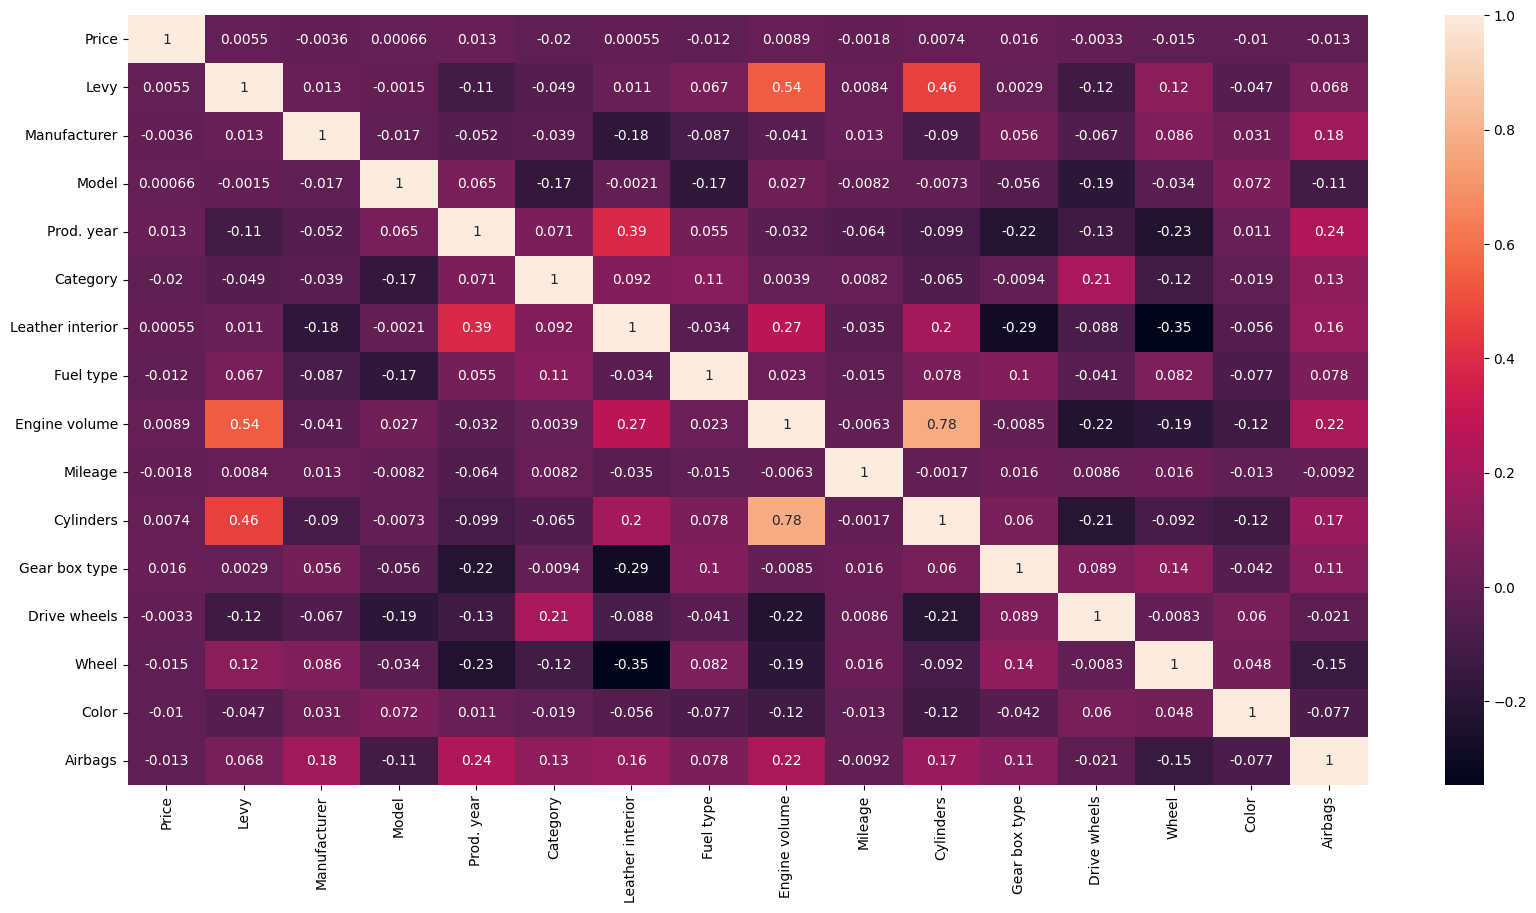

In [41]:
data=df.corr()
plt.figure(figsize=(20,10))
sns.heatmap(data,annot=True)

In [31]:
x=df.drop("Price",axis=1)
y=df["Price"]

In [32]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)

In [33]:
model=LinearRegression()
model.fit(xtrain,ytrain)

LinearRegression()

In [34]:
ypred=model.predict(xtest)
ypred

array([ 8469.85598891,  -353.38173399, 14923.46640999, ...,
       24189.23838081, 10036.40004984, 18284.25981859])

In [35]:
print("Metrics:")
r2=r2_score(ytest,ypred)
print("R2",r2)
N=df.shape[0]
P=df.shape[1]
adj_r2=1-(((1-r2**2)*(N-1))/N-P-1)
print("Adjusted R2",adj_r2)
print("MSE:",mean_squared_error(ytest,ypred))
print("MAE:",mean_absolute_error(ytest,ypred))

Metrics:
R2 -0.01365846023369599
Adjusted R2 17.000239386628667
MSE: 330690355.66097826
MAE: 12794.722924968093


In [36]:
print("Training eff:",model.score(xtrain,ytrain))
print("Testing eff:",model.score(xtest,ytest))

Training eff: 0.001958503308008397
Testing eff: -0.01365846023369599
